In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/seattle-weather.csv")

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

In [ ]:
df.head()

,date,precipitation,temp_max,temp_min,wind,year,month,day,weather_fog,weather_rain,weather_snow,weather_sun
0,2012-01-01,0.0,12.8,5.0,4.7,2012,1,1,False,False,False,False
1,2012-01-02,10.9,10.6,2.8,4.5,2012,1,2,False,True,False,False
2,2012-01-03,0.8,11.7,7.2,2.3,2012,1,3,False,True,False,False
3,2012-01-04,20.3,12.2,5.6,4.7,2012,1,4,False,True,False,False
4,2012-01-05,1.3,8.9,2.8,6.1,2012,1,5,False,True,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[ns]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   year           1461 non-null   int32         
 6   month          1461 non-null   int32         
 7   day            1461 non-null   int32         
 8   weather_fog    1461 non-null   bool          
 9   weather_rain   1461 non-null   bool          
 10  weather_snow   1461 non-null   bool          
 11  weather_sun    1461 non-null   bool          
dtypes: bool(4), datetime64[ns](1), float64(4), int32(3)
memory usage: 80.0 KB


In [ ]:
df.describe()

,date,precipitation,temp_max,temp_min,wind,year,month,day
count,1461,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000
mean,2013-12-31 00:00:00,3.029432,16.439083,8.234771,3.241136,2013.498973,6.522930,15.729637
min,2012-01-01 00:00:00,0.000000,-1.600000,-7.100000,0.400000,2012.000000,1.000000,1.000000
25%,2012-12-31 00:00:00,0.000000,10.600000,4.400000,2.200000,2012.000000,4.000000,8.000000
50%,2013-12-31 00:00:00,0.000000,15.600000,8.300000,3.000000,2013.000000,7.000000,16.000000
75%,2014-12-31 00:00:00,2.800000,22.200000,12.200000,4.000000,2014.000000,10.000000,23.000000
max,2015-12-31 00:00:00,55.900000,35.600000,18.300000,9.500000,2015.000000,12.000000,31.000000
std,NaN,6.680194,7.349758,5.023004,1.437825,1.118723,3.449884,8.803105


In [ ]:
df.isnull()

,date,precipitation,temp_max,temp_min,wind,year,month,day,weather_fog,weather_rain,weather_snow,weather_sun
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1456,False,False,False,False,False,False,False,False,False,False,False,False
1457,False,False,False,False,False,False,False,False,False,False,False,False
1458,False,False,False,False,False,False,False,False,False,False,False,False
1459,False,False,False,False,False,False,False,False,False,False,False,False


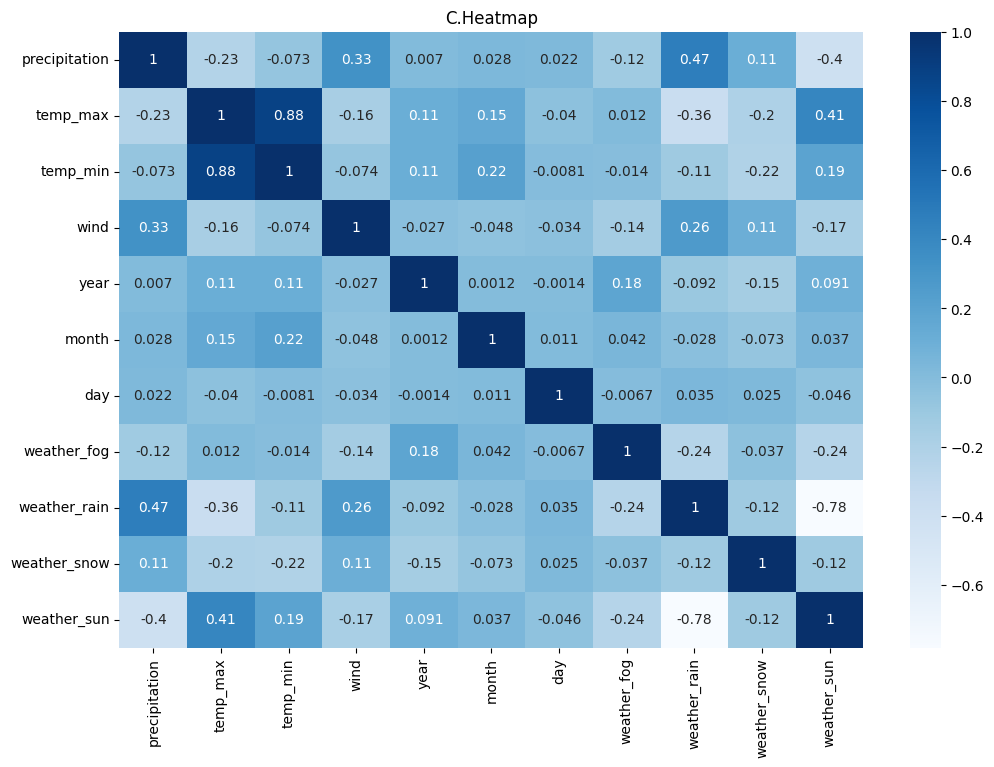

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Blues")
plt.title("C.Heatmap")
plt.show()

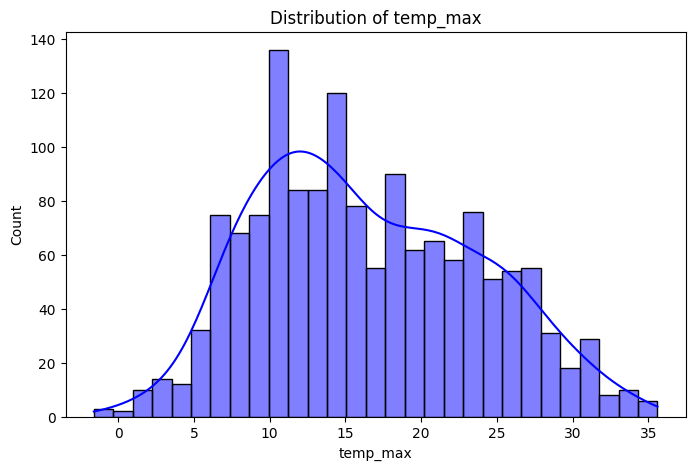

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["temp_max"],bins=29,kde=True,color="blue")
plt.title("Distribution of temp_max")
plt.show()

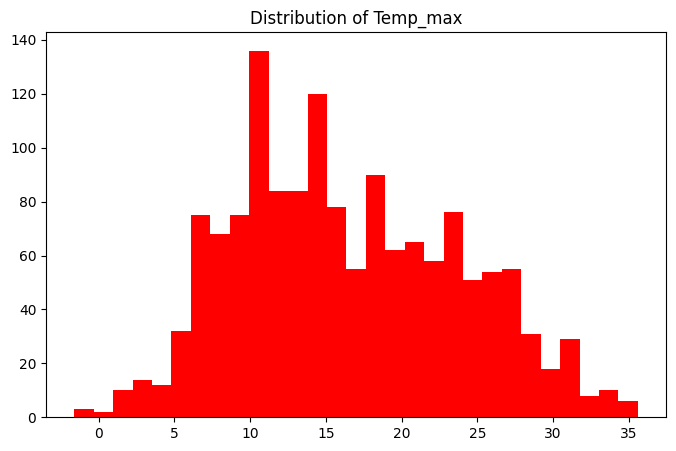

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["temp_max"], bins=29, color="red")
plt.title("Distribution of Temp_max")
plt.show()

In [ ]:
df = pd.get_dummies(df, columns=["weather"], drop_first=True)

In [ ]:
X = df.drop(["temp_max", "date"], axis=1).values
y = df["temp_max"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
n_epochs = 5

In [ ]:
model = SGDRegressor(
    max_iter=n_epochs,
    learning_rate='adaptive',
    eta0=0.01,
    penalty='l2',
    alpha=0.0001,
    early_stopping=True,
    validation_fraction=0.1,
    tol=1e-4,
    random_state=42
)

model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDRegressor(early_stopping=True, learning_rate='adaptive', max_iter=5,
             random_state=42, tol=0.0001)

In [ ]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\n----- MODEL PERFORMANCE -----")
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


----- MODEL PERFORMANCE -----
MSE: 8.661808543318724
RMSE: 2.943095061889562
R² Score: 0.8477926432264938


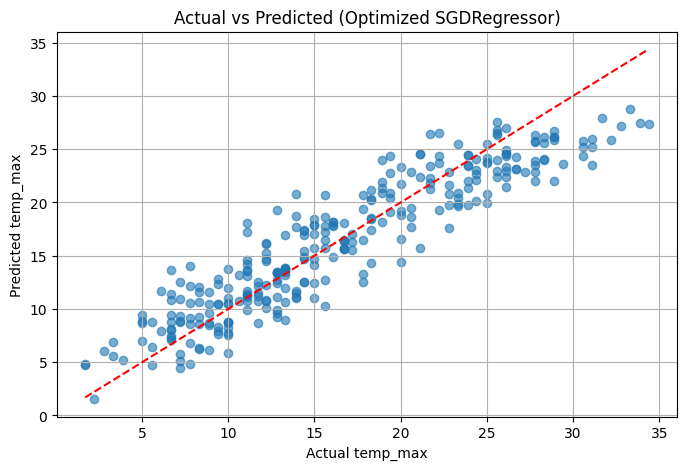

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    "r--"
)
plt.xlabel("Actual temp_max")
plt.ylabel("Predicted temp_max")
plt.title("Actual vs Predicted (Optimized SGDRegressor)")
plt.grid()
plt.show()